# Masses Classification using ResNet50 (Transfer Learning)

* **Model:** ResNet50
* **Lesion:** Masses
* **Image Preprocessor:** Baseline (resizing + resnet50-specific preprocessing)
* **Image View:** CC-Only-View
* **Training Method:** Transfer Learning (with 50 maximum epochs)
* **Classification Threshold Optimization:** Youden's Index (J) and ROC Curve
* **Image-Level Evaluation:** Using Optimal Classification Threshold computed from Youden's Index and ROC Curve
* **Patient-Level Evaluation:** Using Optimal Classification Threshold computed from Optimal Threshold (from Youden's Index and ROC Curve) and grouped-by-patient_id with max() aggregator.
* **Calibration:** ECE Scores and Temperature Scaling
* **Explainability:** Grad-CAM

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 878, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 878 (delta 84), reused 154 (delta 60), pack-reused 693 (from 2)
Receiving objects: 100% (878/878), 24.92 MiB | 26.78 MiB/s, done.
Resolving deltas: 100% (427/427), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.final_results_functions import *
from src.visualizations import *
from src.calibration_scores_functions import *
from src.grad_cam_functions import *
from src.constants import BATCH_SIZE, CLASSES, FINAL_EPOCHS

#### Load Dataset

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training dataset (containing images) and store it in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"

In [ ]:
# Unzip and extract validation dataset (containing images) and store it in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# Unzip and extract testing dataset (containing images) and store it in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training metadata CSV file from drive and store it as dataframe
train_df = pd.read_csv(dataset_root + "/train_data.csv")

In [ ]:
# Extract validation metadata CSV file from drive and store it as dataframe
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Extract testing metadata CSV file from drive and store it as a dataframe
test_df = pd.read_csv(dataset_root + "/test_data.csv")

#### Update 'image_path' for all metadata files

In [ ]:
# Update 'image_path' of training dataframe with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)

In [ ]:
# Update 'image_path' of validation dataframe with new image path source
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Update 'image_path of testing dataframe with new image path source
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

#### Extract Mass data with CC image view

In [ ]:
# Mass-only lesion with CC-Only view training dataframe
train_df_m = train_df.loc[(train_df['abnormality type'] == 'mass') & (train_df['image view'] == 'CC')]

In [ ]:
# Mass-only lesion with CC-Only view validation dataframe
val_df_m = val_df.loc[(val_df['abnormality type'] == 'mass') & (val_df['image view'] == 'CC')]

In [ ]:
# Mass-only lesion with CC-Only view testing dataframe
test_df_m = test_df.loc[(test_df['abnormality type'] == 'mass') & (test_df['image view'] == 'CC')]

#### Class Distributions

In [ ]:
# Class distributions for training data with masses
print(train_df_m['pathology'].value_counts())

pathology
0.0    280
1.0    236
Name: count, dtype: int64


In [ ]:
# Class distribution for validation data with masses
print(val_df_m['pathology'].value_counts())

pathology
0.0    62
1.0    58
Name: count, dtype: int64


In [ ]:
# Class distribution for testing data with masses
print(test_df_m['pathology'].value_counts())

pathology
0.0    79
1.0    69
Name: count, dtype: int64


#### True Labels (validation and testing)

In [ ]:
# Validation set true labels for evaluation
val_true_labels = val_df_m['pathology'].to_numpy()

In [ ]:
# Testing set true labels for evaluation
test_true_labels = test_df_m['pathology'].to_numpy()

#### Buffer size and Early Stopping

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE = len(train_df_m)
# No. of training samples in Mass dataframe for class weight
TOTAL_TRAINING_SAMPLES = len(train_df_m)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

#### Class-Imbalance handling with class weights

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_df_m, CLASSES, TOTAL_TRAINING_SAMPLES)

#### Image preprocessor

In [ ]:
# Image preprocessor
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

#### tf.data Dataset Generation and Preparation (Data Augmentation and Shuffling for training only)

In [ ]:
# Generate training dataset for Mass only
train_dataset = dataset_preparation(train_df_m, baseline_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)

In [ ]:
# Generate validation dataset for Mass only
val_dataset = dataset_preparation(val_df_m, baseline_preprocessor, 0, BATCH_SIZE, training=False)

In [ ]:
# Generate testing dataset for Mass only
test_dataset = dataset_preparation(test_df_m, baseline_preprocessor, 0, BATCH_SIZE, training=False)

## ResNet50 Transfer Learning for Mass Classification with Max 50 epochs

In [ ]:
# Select ResNet50 for training with more epochs
resnet50 = select_model('resnet50')
# Train ResNet50 with more epochs
resnet50_model, _, _ = train_selected_model(resnet50, train_dataset, val_dataset, FINAL_EPOCHS, early_stopping, class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - auc: 0.4648 - loss: 0.8358 - precision: 0.4740 - recall: 0.3475 - val_auc: 0.6221 - val_loss: 0.6757 - val_precision: 0.6800 - val_recall: 0.2931
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - auc: 0.5723 - loss: 0.6527 - precision: 0.5868 - recall: 0.4153 - val_auc: 0.6638 - val_loss: 0.6611 - val_precision: 0.7222 - val_recall: 0.4483
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 365ms/step - auc: 0.6440 - loss: 0.6250 - precision: 0.7032 - recall: 0.4619 - val_auc: 0.6946 - val_loss: 0.6516 - val_precision: 0.7292 - val_recall: 0.6034
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - auc: 0.6577 - loss: 0.6168 - precision: 0.6903 - recall: 0.4534 - val_auc: 0.7120 - val_loss: 0.6488 - val_precision: 0.7200 - val_recall: 0.6207
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 394ms/step - auc: 0.6904 - loss: 0.5763 - precision: 0.7107 - recall: 0.5932 - val_auc: 0.7246 - val_loss: 0.6

In [ ]:
# Save resnet50
resnet50_model.save("/content/drive/MyDrive/CM3070_Final_Project_Models/resnet50_mass.keras")

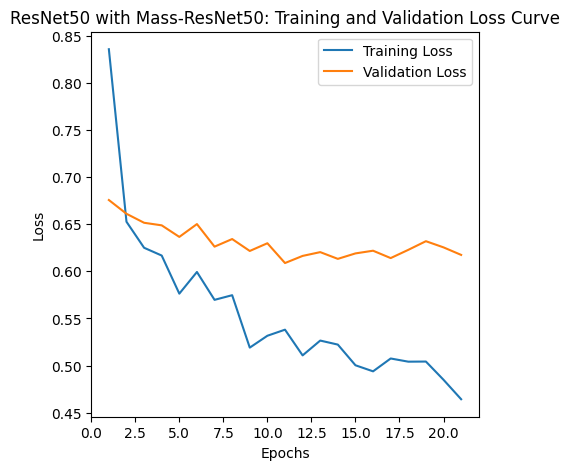

In [ ]:
# Plot training-validation curve
plot_training_validation_loss(resnet50_model.history, 'ResNet50', 'Mass-ResNet50')

### Load Final Trained ResNet50 Model

In [ ]:
resnet50_model = tf.keras.models.load_model("/content/drive/MyDrive/CM3070_Final_Project_Models/resnet50_mass.keras")

## Classification Threshold Optimization using Youden's Index (with Validation Data)

In [ ]:
# Get validation logits from trained model using validation data
val_logits = resnet50_model.predict(val_dataset)
# Compute validation prediction probabilities from validation logits
val_probs = tf.nn.sigmoid(val_logits)

4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step


In [ ]:
# Compute Optimal Youden's Index (J), optimal threshold, true-positive-rate and false-positive-rate using validation probabilities and validation true labels
max_j, j, optimal_threshold_j, thresholds, tpr, fpr = compute_youdens_index_and_optimal_threshold(val_probs, val_true_labels)

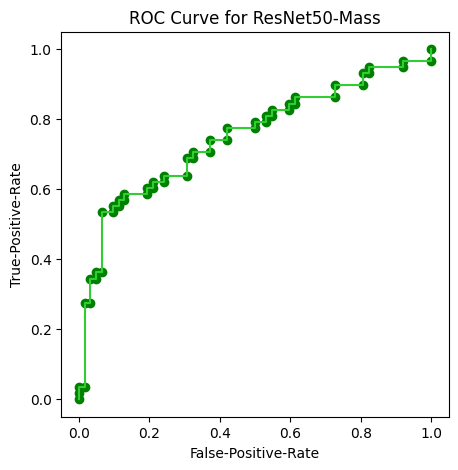

In [ ]:
# Plot ROC Curve
plot_roc_curve(tpr, fpr, "ResNet50-Mass")

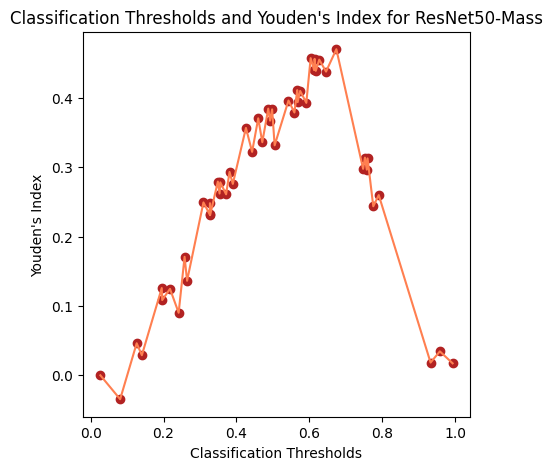

In [ ]:
# Plot Youden's Index
plot_youdens_index(thresholds, j, 'ResNet50-Mass')

In [ ]:
# Threshold based on ROC-Curve
roc_curve_threshold = 0.35

print(f"Youden's Index based threshold: {optimal_threshold_j}")
print(f"ROC-Curve based threshold: {roc_curve_threshold}")

Youden's Index based threshold: 0.6744527220726013
ROC-Curve based threshold: 0.35


#### Thresholds
* Youden's Optimal Cutoff based optimal threshold = 0.6744
* ROC-Curve based optimal threshold = 0.35

## Testing

In [ ]:
# Testing true labels tensor preparation
test_true_labels_tensor = tf.convert_to_tensor(test_df_m['pathology'], dtype=tf.float32)
test_true_labels_tensor = tf.reshape(test_true_labels_tensor, (-1, 1))

**Youden's Optimal Cutoff as Optimal Threshold**

In [ ]:
# Get test logits, predictions and evaluation metrics using optimal threshold based on Youden's Index as classification threshold
test_logits_j, test_preds_j, test_eval_metrics_j, _ = generate_predictions_and_evaluations(resnet50_model, test_dataset, test_true_labels, optimal_threshold_j)

5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - auc: 0.7150 - loss: 0.5748 - precision: 0.7727 - recall: 0.4928


In [ ]:
test_eval_metrics_j

{'pr_auc': 0.7150465250015259,
 'sensitivity': np.float64(0.42028985507246375),
 'specificity': np.float64(0.8860759493670886),
 'precision': np.float64(0.7631578947368421),
 'f1_score': np.float64(0.5420560747663552),
 'accuracy': np.float64(0.668918918918919)}

<Figure size 1000x600 with 0 Axes>

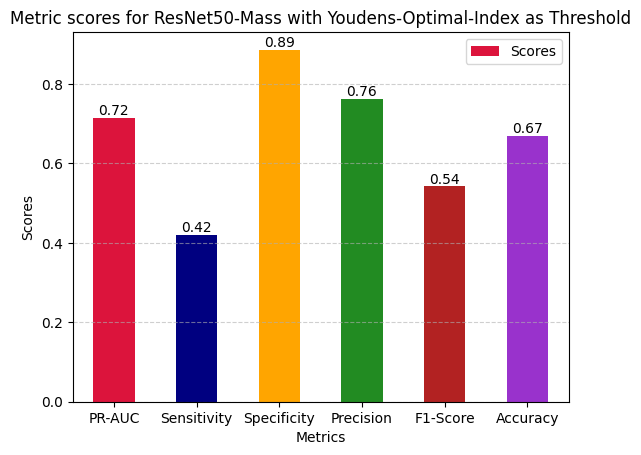

In [ ]:
plot_metrics(test_eval_metrics_j, 'ResNet50-Mass with Youdens-Optimal-Index as Threshold')

**ROC-Curve based threshold as Optimal Threshold**

In [ ]:
# Get test logits, predictions and evaluation metrics using optimal threshold from ROC Curve as classification threshold
test_logits, test_preds, test_eval_metrics, _ = generate_predictions_and_evaluations(resnet50_model, test_dataset, test_true_labels, roc_curve_threshold)

5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - auc: 0.7150 - loss: 0.5748 - precision: 0.7727 - recall: 0.4928


In [ ]:
test_eval_metrics

{'pr_auc': 0.7150465250015259,
 'sensitivity': np.float64(0.8405797101449275),
 'specificity': np.float64(0.46835443037974683),
 'precision': np.float64(0.58),
 'f1_score': np.float64(0.6863905325443788),
 'accuracy': np.float64(0.6418918918918919)}

<Figure size 1000x600 with 0 Axes>

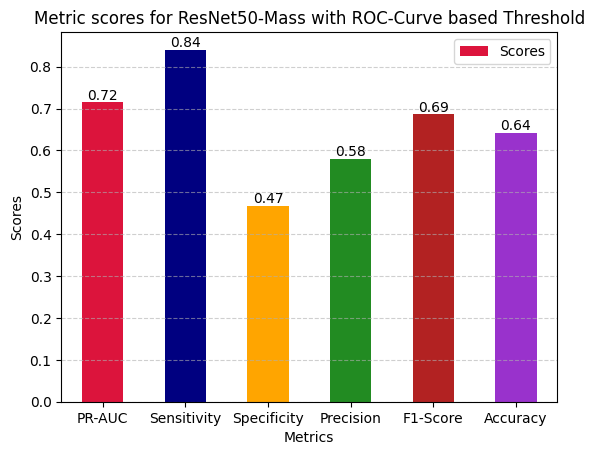

In [ ]:
plot_metrics(test_eval_metrics, 'ResNet50-Mass with ROC-Curve based Threshold')

In [ ]:
SELECTED_OPTIMAL_THRESHOLD = roc_curve_threshold

In [ ]:
# ECE Score before temperature scaling
with tf.device("/CPU:0"):
  ece_before = compute_ece_score(test_logits, test_true_labels_tensor, 10)

### Calibration with Temperature Scaling (using Validation dataset)

In [ ]:
# Validation labels tensor preparation
val_true_labels_tensor = tf.convert_to_tensor(val_df_m['pathology'], dtype=tf.float32)
val_true_labels_tensor = tf.reshape(val_true_labels_tensor, (-1, 1))

In [ ]:
# Get validation logits for temperature scaling
val_logits, _, _, _ = generate_predictions_and_evaluations(resnet50_model, val_dataset, val_true_labels, SELECTED_OPTIMAL_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - auc: 0.7422 - loss: 0.6088 - precision: 0.8421 - recall: 0.5517


In [ ]:
# Temperature variable
temperature = tf.Variable(1.0, trainable=True)
# Temperature optimization
optimized_temperature = temperature_scaling(val_logits, val_true_labels_tensor, temperature)

#### Calibrated logits (Testing dataset)

In [ ]:
# Scale test logits with optimized temperature
scaled_test_logits = test_logits / optimized_temperature

In [ ]:
# Compute ECE Score after temperature scaling
with tf.device("/CPU:0"):
  ece_after = compute_ece_score(scaled_test_logits, test_true_labels_tensor, 10)

In [ ]:
print(f"ECE Score before temperature scaling: {ece_before}")
print(f"ECE Score after temperature scaling: {ece_after}")

ECE Score before temperature scaling: 0.04993848502635956
ECE Score after temperature scaling: 0.05666250362992287


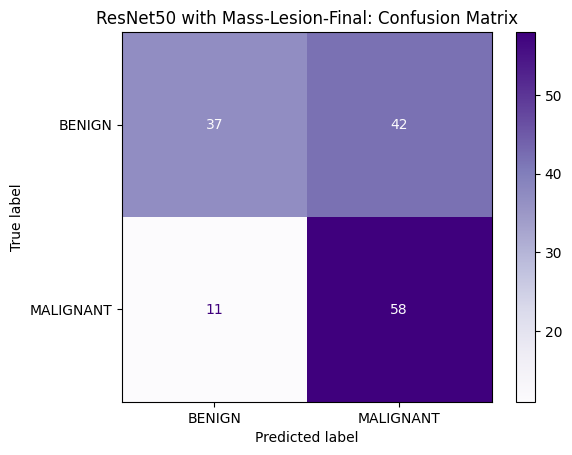

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, test_preds, 'ResNet50', 'Mass-Lesion-Final')

### Patient-Level Evaluation

In [ ]:
patient_level_metrics = patient_level_evaluation_metrics(resnet50_model, test_df_m, test_dataset, SELECTED_OPTIMAL_THRESHOLD)
patient_level_metrics

5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step


{'accuracy': np.float64(0.644927536231884),
 'sensitivity': np.float64(0.8636363636363636),
 'specificity': np.float64(0.4444444444444444),
 'precision': np.float64(0.5876288659793815),
 'f1_score': np.float64(0.6993865030674846)}

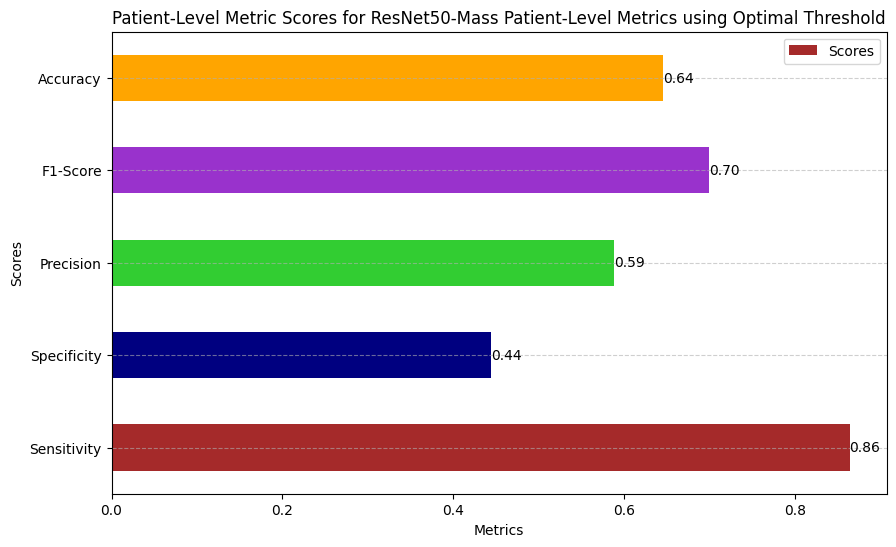

In [ ]:
plot_patient_level_metrics(patient_level_metrics, 'ResNet50-Mass Patient-Level Metrics using Optimal Threshold')

### Grad CAM for Explainability

In [ ]:
# Extract base model and its last convolutional layer
base_resnet50 = resnet50_model.get_layer('resnet50')
last_conv_layer_name = 'conv5_block3_out'

In [ ]:
# Create a copy of test_df_m and add predictions to the copied dataframe
test_gc = test_df_m.copy()
test_gc['prediction'] = test_preds

In [ ]:
# Sample 5 randomly selected images
samples = test_gc.sample(n=5, random_state=42)[['new_image_path', 'abnormality type', 'pathology', 'prediction']]

#### Image Sample 0

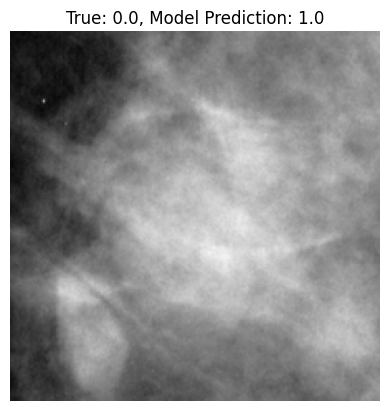

In [ ]:
# Original
original0 = tf.keras.utils.load_img(samples.iloc[0]['new_image_path'])
original0 = original0.resize((224, 224))
plt.imshow(original0)
plt.title(f"True: {samples.iloc[0]['pathology']}, Model Prediction: {samples.iloc[0]['prediction']}")
plt.axis('off')
plt.show()

In [ ]:
# Grad CAM Results for image 0
sample0_gc, pred0_gc = generate_grad_cam_image(samples['new_image_path'].iloc[0], resnet50_model, base_resnet50, last_conv_layer_name)

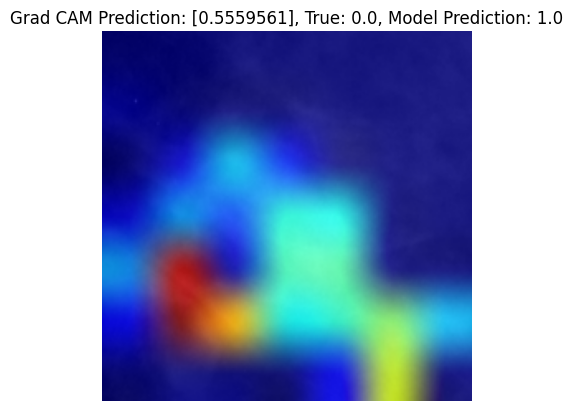

In [ ]:
# Visualize Grad CAM for image 0
plt.imshow(sample0_gc)
plt.title(f"Grad CAM Prediction: {pred0_gc}, True: {samples.iloc[0]['pathology']}, Model Prediction: {samples.iloc[0]['prediction']}")
plt.axis('off')
plt.show()

#### Image Sample 1

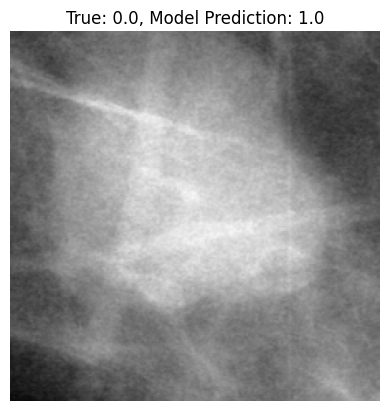

In [ ]:
# Original
original1 = tf.keras.utils.load_img(samples.iloc[1]['new_image_path'])
original1 = original1.resize((224, 224))
plt.imshow(original1)
plt.title(f"True: {samples.iloc[1]['pathology']}, Model Prediction: {samples.iloc[1]['prediction']}")
plt.axis('off')
plt.show()

In [ ]:
# Grad CAM results for image 1
sample1_gc, pred1_gc = generate_grad_cam_image(samples['new_image_path'].iloc[1], resnet50_model, base_resnet50, last_conv_layer_name)

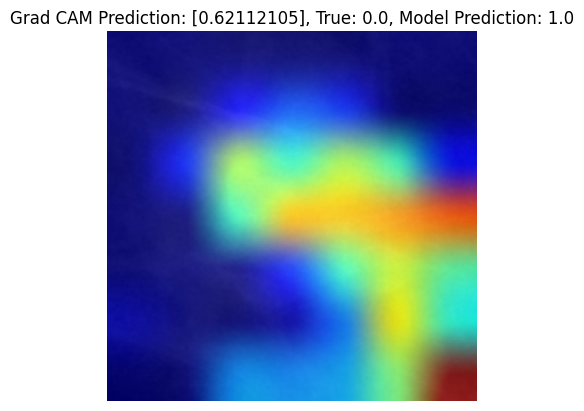

In [ ]:
# Visualize Grad CAM of image 1
plt.imshow(sample1_gc)
plt.title(f"Grad CAM Prediction: {pred1_gc}, True: {samples.iloc[1]['pathology']}, Model Prediction: {samples.iloc[1]['prediction']}")
plt.axis('off')
plt.show()

#### Image Sample 2

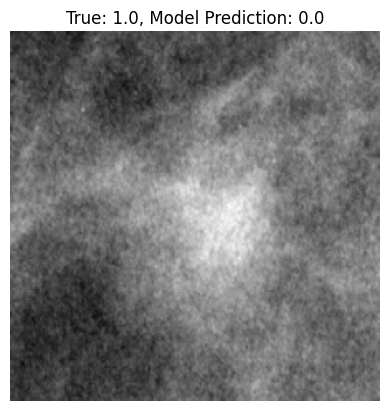

In [ ]:
# Original
original2 = tf.keras.utils.load_img(samples.iloc[2]['new_image_path'])
original2 = original2.resize((224, 224))
plt.imshow(original2)
plt.title(f"True: {samples.iloc[2]['pathology']}, Model Prediction: {samples.iloc[2]['prediction']}")
plt.axis('off')
plt.show()

In [ ]:
# Grad CAM of image sample 2
sample2_gc, pred2_gc = generate_grad_cam_image(samples['new_image_path'].iloc[2], resnet50_model, base_resnet50, last_conv_layer_name)

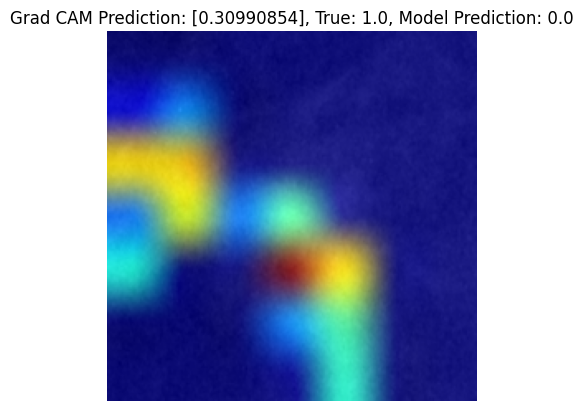

In [ ]:
# Visualize Grad CAM of image 2
plt.imshow(sample2_gc)
plt.title(f"Grad CAM Prediction: {pred2_gc}, True: {samples.iloc[2]['pathology']}, Model Prediction: {samples.iloc[2]['prediction']}")
plt.axis('off')
plt.show()

#### Image Sample 3

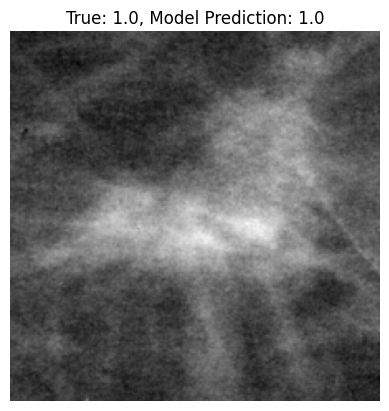

In [ ]:
# Original
original3 = tf.keras.utils.load_img(samples.iloc[3]['new_image_path'])
original3 = original3.resize((224, 224))
plt.imshow(original3)
plt.title(f"True: {samples.iloc[3]['pathology']}, Model Prediction: {samples.iloc[3]['prediction']}")
plt.axis('off')
plt.show()

In [ ]:
# Grad CAM of image sample 3
sample3_gc, pred3_gc = generate_grad_cam_image(samples['new_image_path'].iloc[3], resnet50_model, base_resnet50, last_conv_layer_name)

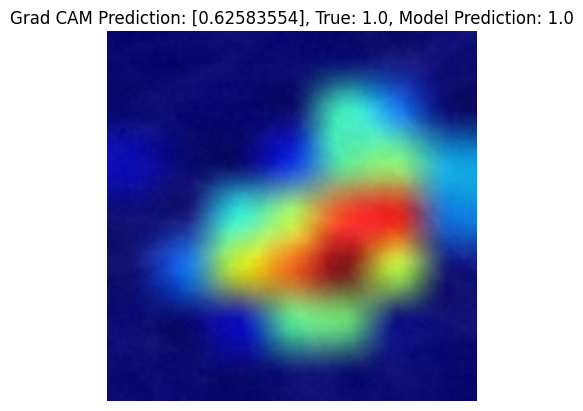

In [ ]:
# Visualzie grad cam of image 3
plt.imshow(sample3_gc)
plt.title(f"Grad CAM Prediction: {pred3_gc}, True: {samples.iloc[3]['pathology']}, Model Prediction: {samples.iloc[3]['prediction']}")
plt.axis('off')
plt.show()

#### Image Sample 4

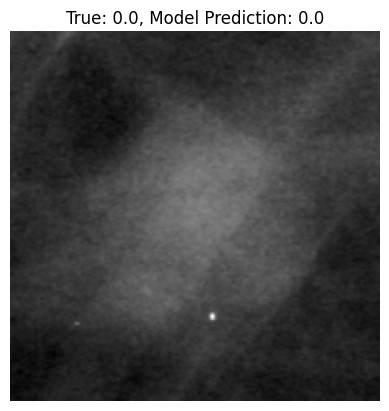

In [ ]:
# Original
original4 = tf.keras.utils.load_img(samples.iloc[4]['new_image_path'])
original4 = original4.resize((224, 224))
plt.imshow(original4)
plt.title(f"True: {samples.iloc[4]['pathology']}, Model Prediction: {samples.iloc[4]['prediction']}")
plt.axis('off')
plt.show()

In [ ]:
# Grad CAM of image sample 4
sample4_gc, pred4_gc = generate_grad_cam_image(samples['new_image_path'].iloc[4], resnet50_model, base_resnet50, last_conv_layer_name)

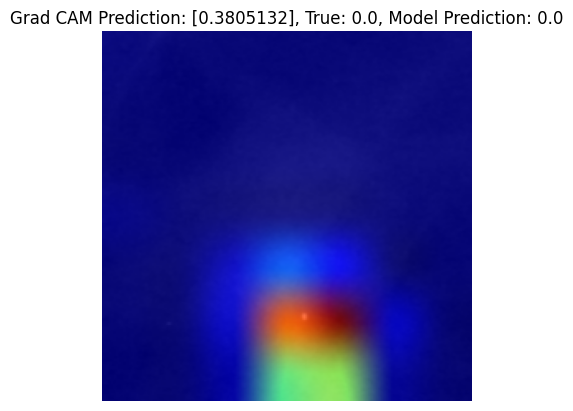

In [ ]:
# Visualize grad cam of image 4
plt.imshow(sample4_gc)
plt.title(f"Grad CAM Prediction: {pred4_gc}, True: {samples.iloc[4]['pathology']}, Model Prediction: {samples.iloc[4]['prediction']}")
plt.axis('off')
plt.show()